In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
df = pd.read_csv("student-mat.csv", sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [11]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [12]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [13]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


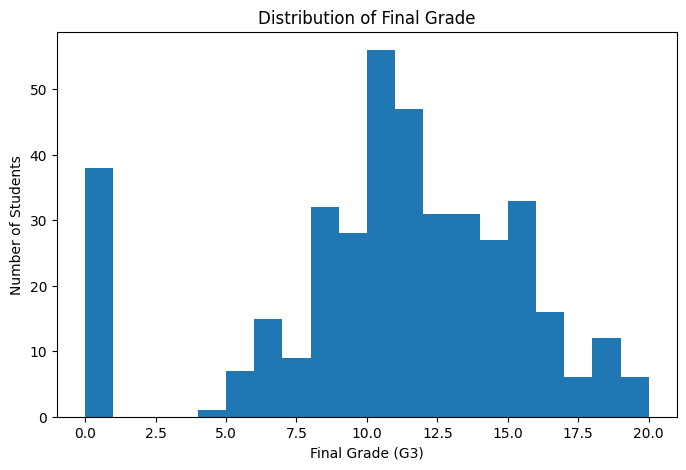

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["G3"], bins=20)
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Grade")
plt.show()

In [15]:
numeric_df = df.select_dtypes(include=["int64"])

corr = numeric_df.corr()

corr["G3"].sort_values(ascending=False)

,G3
G3,1.000000
G2,0.904868
G1,0.801468
Medu,0.217147
Fedu,0.152457
studytime,0.097820
famrel,0.051363
absences,0.034247
freetime,0.011307
Walc,-0.051939


In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

import joblib
df = pd.read_csv("student-mat.csv", sep=';')
TOTAL_PERIODS = 200
PERIODS_PER_DAY = 6


df["attendance_percentage"] = (
    (TOTAL_PERIODS - (df["absences"] * PERIODS_PER_DAY))
    / TOTAL_PERIODS
) * 100
numeric_df = df.select_dtypes(include=["int64","float64"])

corr = numeric_df.corr()

corr["G3"].sort_values(ascending=False)


,G3
G3,1.000000
G2,0.904868
G1,0.801468
Medu,0.217147
Fedu,0.152457
studytime,0.097820
famrel,0.051363
absences,0.034247
freetime,0.011307
attendance_percentage,-0.034247


In [23]:
features = [
    "studytime",
    "attendance_percentage",
    "G1",
    "G2"
]


X = df[features]

y = df["G3"]
X.head()

,studytime,attendance_percentage,G1,G2
0,2,82.0,5,6
1,2,88.0,5,5
2,2,70.0,7,8
3,3,94.0,15,14
4,2,88.0,6,10


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
#LINEAR REGRESSION MODEL
lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)


lr_pred = lr_model.predict(X_test)
print("MAE:",
      mean_absolute_error(y_test, lr_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2 Score:",
      r2_score(y_test, lr_pred))

MAE: 1.312574939624357
RMSE: 2.044254242110515
R2 Score: 0.7961977189442984


In [27]:
#Decision Tree Model
dt_model = DecisionTreeRegressor(
    random_state=42
)


dt_model.fit(
    X_train,
    y_train
)


dt_pred = dt_model.predict(X_test)
print("MAE:",
      mean_absolute_error(y_test, dt_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, dt_pred)))

print("R2 Score:",
      r2_score(y_test, dt_pred))

MAE: 1.0949367088607596
RMSE: 1.8512739370156481
R2 Score: 0.8328599224830432


In [28]:
#Random Forest Model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)


rf_model.fit(
    X_train,
    y_train
)


rf_pred = rf_model.predict(X_test)
print("MAE:",
      mean_absolute_error(y_test, rf_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 Score:",
      r2_score(y_test, rf_pred))

MAE: 1.1312002210166767
RMSE: 1.8131487450436201
R2 Score: 0.839673211737818


In [29]:
#COMPARISON OF THE ABOVE THREE MODELS
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE":[
        mean_absolute_error(y_test,lr_pred),
        mean_absolute_error(y_test,dt_pred),
        mean_absolute_error(y_test,rf_pred)
    ]
})


results

,Model,MAE
0,Linear Regression,1.312575
1,Decision Tree,1.094937
2,Random Forest,1.131200


In [30]:
from sklearn.metrics import r2_score


print("Linear Regression R2:",
      r2_score(y_test, lr_pred))


print("Decision Tree R2:",
      r2_score(y_test, dt_pred))


print("Random Forest R2:",
      r2_score(y_test, rf_pred))

Linear Regression R2: 0.7961977189442984
Decision Tree R2: 0.8328599224830432
Random Forest R2: 0.839673211737818


In [31]:
# Training predictions

dt_train_pred = dt_model.predict(X_train)
rf_train_pred = rf_model.predict(X_train)


print("Decision Tree Training MAE:",
      mean_absolute_error(y_train, dt_train_pred))

print("Decision Tree Testing MAE:",
      mean_absolute_error(y_test, dt_pred))


print("\nRandom Forest Training MAE:",
      mean_absolute_error(y_train, rf_train_pred))

print("Random Forest Testing MAE:",
      mean_absolute_error(y_test, rf_pred))

Decision Tree Training MAE: 0.21835443037974683
Decision Tree Testing MAE: 1.0949367088607596

Random Forest Training MAE: 0.4825301009644364
Random Forest Testing MAE: 1.1312002210166767


In [32]:
from sklearn.ensemble import RandomForestRegressor


rf_model_tuned = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)


rf_model_tuned.fit(
    X_train,
    y_train
)


rf_tuned_pred = rf_model_tuned.predict(X_test)


print("Random Forest Tuned MAE:",
      mean_absolute_error(y_test, rf_tuned_pred))


print("Random Forest Tuned R2:",
      r2_score(y_test, rf_tuned_pred))

Random Forest Tuned MAE: 1.1180577042894693
Random Forest Tuned R2: 0.842364201698637


In [33]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model_tuned.feature_importances_
})


feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


feature_importance

,Feature,Importance
3,G2,0.864522
1,attendance_percentage,0.121866
2,G1,0.009523
0,studytime,0.004089


In [34]:
import joblib
import os

# create models folder if not exists
os.makedirs("models", exist_ok=True)


# save trained model
joblib.dump(
    rf_model_tuned,
    "models/student_model.pkl"
)


# save feature names
joblib.dump(
    list(X.columns),
    "models/features.pkl"
)


print("Model saved successfully!")

Model saved successfully!


In [37]:
import joblib

# Load saved model
saved_model = joblib.load("models/student_model.pkl")

# Check model type
print(type(saved_model))
print(saved_model)
saved_features = joblib.load("models/features.pkl")

print(saved_features)

<class 'sklearn.ensemble._forest.RandomForestRegressor'>
RandomForestRegressor(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                      n_estimators=200, random_state=42)
['studytime', 'attendance_percentage', 'G1', 'G2']


In [38]:
import os

os.listdir("models")

['student_model.pkl', 'features.pkl']

In [39]:
import joblib
import pandas as pd

# Load saved model
model = joblib.load("models/student_model.pkl")

# Create sample input
test_data = pd.DataFrame({
    "studytime": [3],
    "attendance_percentage": [90],
    "G1": [12],
    "G2": [14]
})


# Prediction
prediction = model.predict(test_data)

print("Predicted G3:", prediction[0])

Predicted G3: 14.177316209504594
